-----
# AM10: Computing for Science and Engineering - Module 2

## Lab 06: Finding Roots
-----

### Learning objectives:

- Implementing bracketing of roots

- Implementing the Bisection method for finding roots

- Applications: Finding roots of known functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Implementing bracketing of roots

You have seen how to bracket roots of polynomial functions in the lecture. In the exercise below, we will now write a function that can output the bracketed roots in an array representing a known or unknown function. We will not assume any knowledge of how many roots there are in the range of interest.

Let's first think of how the code for this function might differ from the code in the lecture. 

We will still need a `for` loop to go over each element in the array `fx` and find its product with the next element. However, since we don't necessarily know how many roots there are in `fx` for the given range of `x`, we will not be initialize an array to hold the found brackets in.

The way we can solve this problem simply is by using lists instead of arrays. A `list`, as you might remember from Lab 02, also allow us to hold a series of elements as one collection. Although lists are not as efficient as arrays when the number of elements becomes large, they are still useful since one can initialize a list without specifying how many elements it contains and adding elements at the end of a list can be easily done with the `append` method. 

As a reminder, the code below initializes an empty list. Then adds two elements at the end one after the other using `append`.

In [5]:
list1 = []  # initialize empty list
list1.append(3)  # append 3 at the end of list1
print(list1)
a = 5
list1.append(a)  # append the variable a at the end of list1
print(list1)

[3]
[3, 5]


Now, let's get back to bracketing. 

### *Breakout Room (10 mins)*

Create a function called `bracketing_method` to bracket roots. The inputs arguments of `bracketing_method` should be 

1. an array containing the independent variable defined in a desired range
2. an array containing the values of the function to be bracketed for the independent variable, 

The `bracketing_method` function should print and return the number of roots found in the provided range and the list of all the brackets. 

In [6]:
def bracketing_method(x, fx):
    
    ''' This function can bracket the roots of a given known or unknown function
        Input:
           x : Discretized independant variable [array]
           fx : Discretized function [array]
        Output: 
           xa : left bracket [list] 
           xb : right bracket [list]
           nr : number of roots [scalar]
    '''
    
    # initialize number of roots
    nr = 0
    
    # initialize empty list to hold left brackets
    xa = []
     
    # initialize empty list to hold right brackets
    xb = []
    
    # run loop for all elements of x but last 
    for i in range(len(x)-1):
        # take product of nth and (n+1)th value of fx
        fprod = fx[i] * fx[i+1]
        # check sign for zero-crossing
        if fprod < 0:
            # append lists
            xa.append(x[i])
            xb.append(x[i+1])
            # increment nr
            nr = nr + 1
    # print out results
    print('Number of Roots =', nr)
    print('Brackets:')
    for i in range(nr):
        print(xa[i], xb[i])
    # return xa, xb, nr
    return xa, xb, nr

Now that we have written our function, let's go ahead and test it on a simple function. Below is a function that is defined in a way such that it's number of roots as well the roots themselves are obviuous. 
\begin{equation}
f(x) = (x-1)(x-2)(x-3)(x-4)
\end{equation}

In [7]:
def fofx(x):
    y = (x - 1)*(x - 2)*(x - 3)*(x - 4)
    return y

We will test your code for `bracketing_method` on $f(x)$ defined above. Let's start by plotting the function `fofx` from 0 to 5. Then use `bracketing_method` and replot the function along with the found brackets identified by `+` signs in the figure.

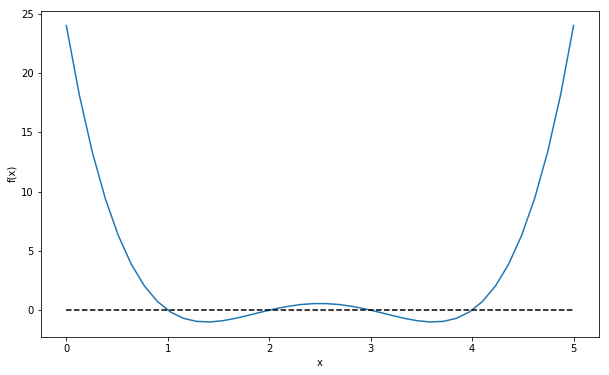

In [8]:
nx = 40  # define number of points 
xmin = 0  # define range min
xmax = 5  # define range max
x = np.linspace(xmin, xmax, nx)  # generate the array for the independent variable
fx = fofx(x)  # generate the array for the discretized function

# Plot fofx
fig1, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(x, fx)
ax1.plot([xmin, xmax], [0, 0], 'k--')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
plt.show(fig1)

Number of Roots = 4
Brackets:
0.8974358974358974 1.0256410256410255
1.923076923076923 2.051282051282051
2.9487179487179485 3.0769230769230766
3.974358974358974 4.102564102564102


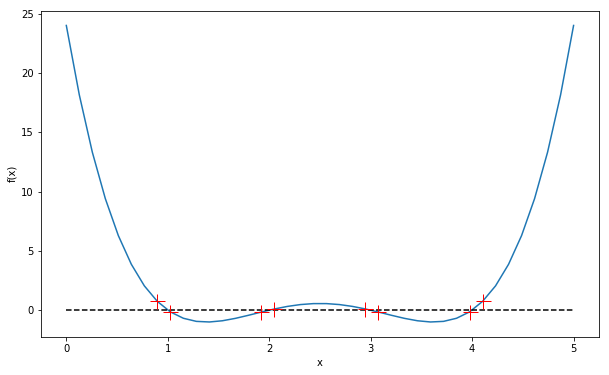

In [10]:
# call bracketing_method
xa1, xb1, nr1 = bracketing_method(x, fx)

# Plot fofx and the brackets
fig2, ax2 = plt.subplots(figsize=(10,6))
ax2.plot(x, fx)
ax2.plot([xmin, xmax], [0, 0], 'k--')
for i in range(nr1):
    ax2.plot(xa1[i], fofx(xa1[i]), 'r+', markersize=15)
    ax2.plot(xb1[i], fofx(xb1[i]), 'r+', markersize=15)
ax2.set_xlabel('x')
ax2.set_ylabel('f(x)')
plt.show(fig2)

In [16]:
print(type(xa1))
test = np.array(xa1)
print(type(test))

<class 'list'>
<class 'numpy.ndarray'>


### Main Room Exercise 1:

Now, bracket the roots for the function below in the range $-\pi$ to $\pi$ using 40 points and plot the function along with the brackets indicated by `+` signs on the curve. 
$$ g(x) = \sin{x} - \frac{x}{2} $$

In [17]:
# define gofx
def gofx(x):
    y = np.sin(x) - x / 2
    return y

Number of Roots = 3
Brackets:
-2.0138414446088415 -1.8527341290401345
-0.08055365778435375 0.0805536577843533
1.852734129040134 2.0138414446088415


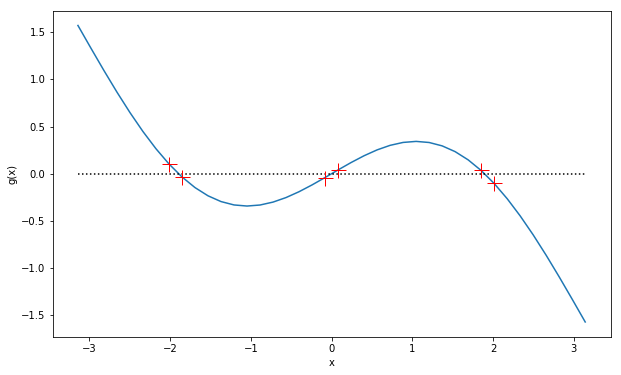

In [18]:
# define number of points 
nx = 40

# define range min
xmin = -np.pi

# define range max
xmax = np.pi

# generate the array for x
x = np.linspace(xmin, xmax, nx)

# generate the array for gx
gx = gofx(x)

# call bracketing_method
xa2, xb2, nr2 = bracketing_method(x, gx)

# Plot gofx and the brackets
fig3, ax3 = plt.subplots(figsize=(10,6))
ax3.plot(x, gx)
ax3.plot([xmin, xmax], [0, 0], 'k:')
for i in range(nr2):
    ax3.plot(xa2[i], gofx(xa2[i]), 'r+', markersize=15)
    ax3.plot(xb2[i], gofx(xb2[i]), 'r+', markersize=15)
ax3.set_xlabel('x')
ax3.set_ylabel('g(x)')
plt.show(fig3)

## Implementing the Bisection Method

Once we know an interval, *i.e.*, a bracket, in which a root exists, one of the easiest ways to approximately find the root is to simply take the mid-point (or average) of the bracket. 

Then, we can calculate the value of our function at that midpoint and check its sign. Depending on the sign of the function at the mid-point, we can replace on of the brackets and repeat these steps over and over. 

Generalizing the above gives us the following update equation.
\begin{equation}
x_{n+1} = \frac{x_n + x_{n-1}}{2}
\end{equation}

In the exercises below, we will implement this technique.

### *Breakout Room (10 mins)*

Discuss and complete the code below to create the `bisection` function. The input arguments for this function should be 

1. a python function representing the mathematical function whose roots are desired
2. the bracket (or interval), `xa` and `xb`, in which the root exists 
3. the convergence tolerance value at which the iteration loop should stop. 

`bisection` should return the value of the root obtained and the number of iterations performed to find each of the roots. Make sure to safeguard against very slowly converging or non-converging cases using a condition for maximum number of iterations.

In [27]:
def bisection(f, xa, xb, toler):
    
    ''' This function can find the roots of a given known function using the Bisection method
        Input:
           f : Python function representing the mathematical expression whose roots are desired [func]
           xa : left bracket [scalar]
           xb : right bracket
           toler : Tolerance for convergance [scalar]
        Output: 
           xroot : value of root [scalar] 
           num_iter : number of iterations to convergence [scalar]
    '''
    
    # maximum number of iterations before exiting the function
    max_iter = 500
    
    # use left bracket as trial root
    xroot = xa
    
    # error at the initial trial root
    ferror = np.absolute(f(xroot))
    
    # initiale number of iterations
    num_iter = 0
    
    # run loop until convergence to the tolerance value
    while ferror > toler:
    
        # check whether maximum iterations have reached
        if num_iter < max_iter:
        
            # generate new trial root by taking mid-point of bracket
            xroot = (xa + xb) / 2

            # check sign for zero-corssing and replace one of the bracket
            frod = f(xroot) * f(xa)
            if frod < 0:
                xb = xroot
            else: 
                xa = xroot
            # recalculate error
            ferror = np.absolute(f(xroot))
            
            # increment number of iterations
            num_iter = num_iter + 1
            
        else:
            print('maximum iterations reached')
            break
        
    # return root and number of iterations
    return xroot, num_iter

### Main Room Exercise 2:

Let's test the `bisection` function and find the roots of the functions $f(x)$ and $g(x)$ defined above. Use the brackets of `fofx` and `gofx` found from the first section above, *i.e.* `xa1`, `xb1` and `xa2`, `xb2` respectively. Use a tolerance value of 1e-9.

In [28]:
#define tolerance
toler = 1e-9

# finding roots of fofx
for i in range(nr1):
    xroot, num_iter = bisection(fofx, xa1[i], xb1[i], toler)
    print('Root', i+1, ':', xroot, ',', 'iteration:', num_iter)

Root 1 : 1.0000000000955203 , iteration: 28
Root 2 : 2.0000000001910405 , iteration: 27
Root 3 : 2.9999999998089595 , iteration: 27
Root 4 : 3.9999999999044795 , iteration: 28


In [29]:
# finding roots of gofx
#define tolerance
toler = 1e-9

# finding roots of fofx
for i in range(nr2):
    xroot, num_iter = bisection(gofx, xa2[i], xb2[i], toler)
    print('Root', i+1, ':', xroot, ',', 'iteration:', num_iter)

Root 1 : -1.895494266023196 , iteration: 22
Root 2 : -2.220446049250313e-16 , iteration: 1
Root 3 : 1.895494266023196 , iteration: 22
